<ipython-input-5-0a0c5d24cb54>:78: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W1[0][0] = W1[0][0] - alpha * dJdW1_11
<ipython-input-5-0a0c5d24cb54>:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W1[0][1] = W1[0][1] - alpha * dJdW1_12
<ipython-input-5-0a0c5d24cb54>:80: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W1[1][0] = W1[1][0] - alpha * dJdW1_21
<ipython-input-5-0a0c5d24cb54>:81: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is de

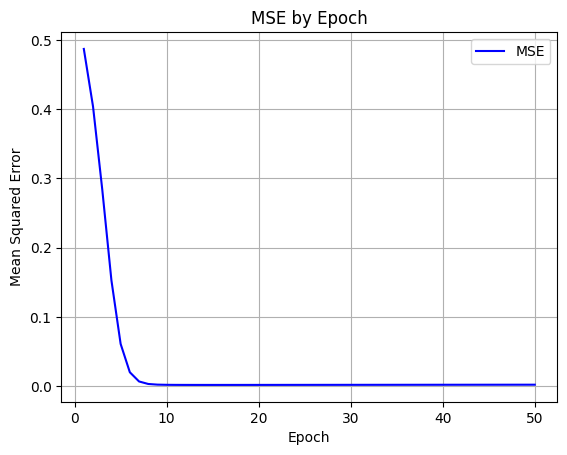

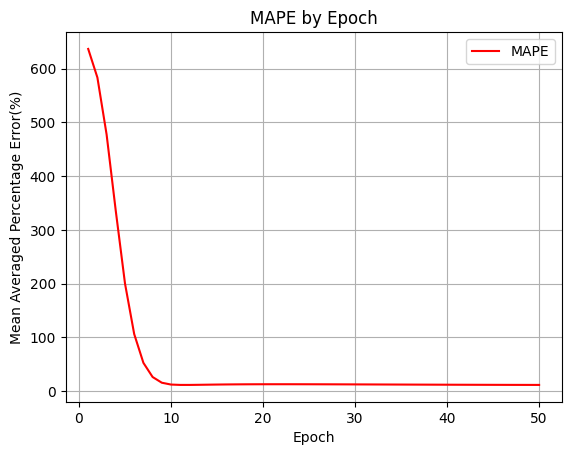

In [5]:
# MLP for numpy
import numpy as np
import matplotlib.pyplot as plt

# Generating dataset for regression
np.random.seed(0)
samples = 1000

x1 = np.random.uniform(0,1,samples)
x2 = np.random.uniform(0,1,samples)


# Combine the features into a NumPy array
Input = np.column_stack((x1,x2))

# Target
y = 2*x1 + 3*x2 - 1

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

def diff_sigmoid(z):
  return sigmoid(z) * (1 - sigmoid(z))

INPUT_LAYER_SIZE = 2
HIDDEN_LAYER_SIZE = 3
OUTPUT_LAYER_SIZE = 1

# Weight and bias
W1 = np.random.rand(INPUT_LAYER_SIZE, HIDDEN_LAYER_SIZE)
b1 = np.random.rand(HIDDEN_LAYER_SIZE)
W2 = np.random.rand(HIDDEN_LAYER_SIZE, OUTPUT_LAYER_SIZE)
b2 = np.random.rand(OUTPUT_LAYER_SIZE)

# Learning rate
alpha = 0.01
epochs = 50

MSE_list, MAPE_list = [], []

for epoch in range(epochs):
  MSE, MAPE = 0, 0
  for i in range(samples):
    x = Input[i]

    # Feed Forward
    z_tilde = (x @ W1).reshape(-1,1) + b1.reshape(-1,1)
    z = sigmoid(z_tilde)
    y_pred = (z.T @ W2).reshape(-1,1) + b2.reshape(-1,1)

    #Calculation thr error
    J = 1/2 * (y_pred - y[i])**2
    MSE += J
    MAPE += 100 * np.abs((y_pred - y[i]) / y[i])

    # Backpropagation
    # Output layer -> Hidden layer
    dJdY = y_pred - y[i]
    dJdW2_11 = z[0] * dJdY
    dJdW2_12 = z[1] * dJdY
    dJdW2_13 = z[2] * dJdY
    dJdb2 = dJdY
    dJdZ1 = W2[0] * dJdY
    dJdZ2 = W2[1] * dJdY
    dJdZ3 = W2[2] * dJdY

    # Hidden layer -> Input layer
    dJdW1_11 = x[0] * diff_sigmoid(z_tilde[0]) * dJdZ1
    dJdW1_12 = x[1] * diff_sigmoid(z_tilde[0]) * dJdZ1
    dJdW1_21 = x[0] * diff_sigmoid(z_tilde[1]) * dJdZ2
    dJdW1_22 = x[1] * diff_sigmoid(z_tilde[1]) * dJdZ2
    dJdW1_31 = x[0] * diff_sigmoid(z_tilde[2]) * dJdZ3
    dJdW1_32 = x[1] * diff_sigmoid(z_tilde[2]) * dJdZ3
    dJdb1_11 = dJdZ1 * diff_sigmoid(z_tilde[0])
    dJdb1_12 = dJdZ2 * diff_sigmoid(z_tilde[1])
    dJdb1_13 = dJdZ3 * diff_sigmoid(z_tilde[2])
    # Update
    W1[0][0] = W1[0][0] - alpha * dJdW1_11
    W1[0][1] = W1[0][1] - alpha * dJdW1_12
    W1[1][0] = W1[1][0] - alpha * dJdW1_21
    W1[1][1] = W1[1][1] - alpha * dJdW1_22
    W1[0][2] = W1[0][2] - alpha * dJdW1_31
    W1[1][2] = W1[1][2] - alpha * dJdW1_32
    b1[0] = b1[0] - alpha * dJdb1_11
    b1[1] = b1[1] - alpha * dJdb1_12
    b1[2] = b1[2] - alpha * dJdb1_13
    W2[0][0] = W2[0][0] - alpha * dJdW2_11
    W2[1][0] = W2[1][0] - alpha * dJdW2_12
    W2[2][0] = W2[2][0] - alpha * dJdW2_13
    b2[0] = b2[0] - alpha * dJdb2
  MSE, MAPE = MSE / samples, MAPE / samples
  MSE_list.append(np.squeeze(MSE))
  MAPE_list.append(np.squeeze(MAPE))

plt.figure()
plt.plot(np.arange(1,epochs+1), MSE_list, label='MSE', linewidth=1.5, color='b')
#plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('MSE by Epoch')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(np.arange(1,epochs+1), MAPE_list, label='MAPE', linewidth=1.5, color='r')
#plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Mean Averaged Percentage Error(%)')
plt.title('MAPE by Epoch')
plt.legend()
plt.grid(True)
plt.show()
